## Global Ecommerce Sales Analysis
This notebook provides comprehensive analysis of global ecommerce sales data including revenue trends, customer segments, regional performance, and profit drivers.

In [25]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [26]:
# Load the dataset
df = pd.read_csv("/kaggle/input/datasets/muhammadaammartufail/global-e-commerce-sales-and-customer-data/global_ecommerce_sales.csv")
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%Y-%m-%d')
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (2000, 15)

First few rows:


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


## Data Overview & Summary Statistics

In [27]:
# Dataset Information
print("="*60)
print("DATA INFORMATION")
print("="*60)
print(f"\nTotal Orders: {len(df):,}")
print(f"Date Range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")
print(f"Countries: {df['Country'].nunique()}")
print(f"Regions: {df['Region'].nunique()}")
print(f"Product Categories: {df['Product_Category'].nunique()}")
print(f"Customer Segments: {df['Customer_Segment'].nunique()}")

print("\n" + "="*60)
print("FINANCIAL SUMMARY")
print("="*60)
print(f"Total Sales: ${df['Total_Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Shipping Cost: ${df['Shipping_Cost'].sum():,.2f}")
print(f"Profit Margin: {(df['Profit'].sum() / df['Total_Sales'].sum() * 100):.2f}%")
print(f"Average Order Value: ${df['Total_Sales'].mean():.2f}")
print(f"Average Profit per Order: ${df['Profit'].mean():.2f}")

DATA INFORMATION

Total Orders: 2,000
Date Range: 2023-01-02 to 2025-12-31
Countries: 20
Regions: 5
Product Categories: 4
Customer Segments: 3

FINANCIAL SUMMARY
Total Sales: $484,559.34
Total Profit: $158,872.32
Total Shipping Cost: $25,804.24
Profit Margin: 32.79%
Average Order Value: $242.28
Average Profit per Order: $79.44


## 1. Sales Performance by Country

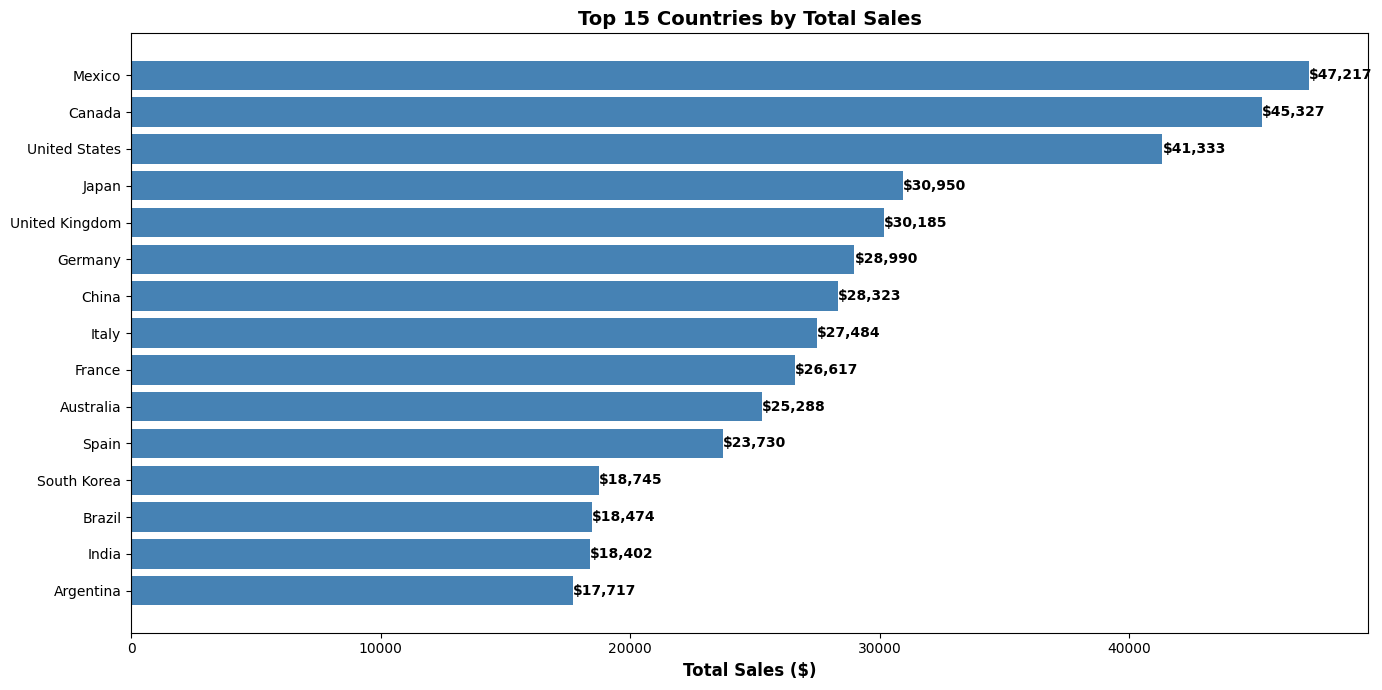


Top 10 Countries by Sales:
                Total_Sales  Total_Profit  Order_Count  Profit_Margin
Country                                                              
Mexico             47217.30      15949.44          203          33.78
Canada             45326.55      15320.95          179          33.80
United States      41332.53      13979.70          196          33.82
Japan              30950.19       9826.31          124          31.75
United Kingdom     30185.46      10185.32          106          33.74
Germany            28989.73       9518.07           95          32.83
China              28322.85       9028.07          109          31.88
Italy              27484.38       9125.06          105          33.20
France             26616.81       8973.46          105          33.71
Australia          25287.72       8072.37          107          31.92


In [35]:
# Top 15 Countries by Total Sales
fig, ax = plt.subplots(figsize=(14, 7))
country_sales = df.groupby('Country')['Total_Sales'].sum().sort_values(ascending=False).head(15)
bars = ax.barh(range(len(country_sales)), country_sales.values, color='steelblue')
ax.set_yticks(range(len(country_sales)))
ax.set_yticklabels(country_sales.index)
ax.set_xlabel('Total Sales ($)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Countries by Total Sales', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'${width:,.0f}', 
            ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top countries details
print("\nTop 10 Countries by Sales:")
top_countries = df.groupby('Country').agg({
    'Total_Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).sort_values('Total_Sales', ascending=False).head(10)
top_countries.columns = ['Total_Sales', 'Total_Profit', 'Order_Count']
top_countries['Profit_Margin'] = (top_countries['Total_Profit'] / top_countries['Total_Sales'] * 100).round(2)
print(top_countries)

## 2. Product Category Analysis

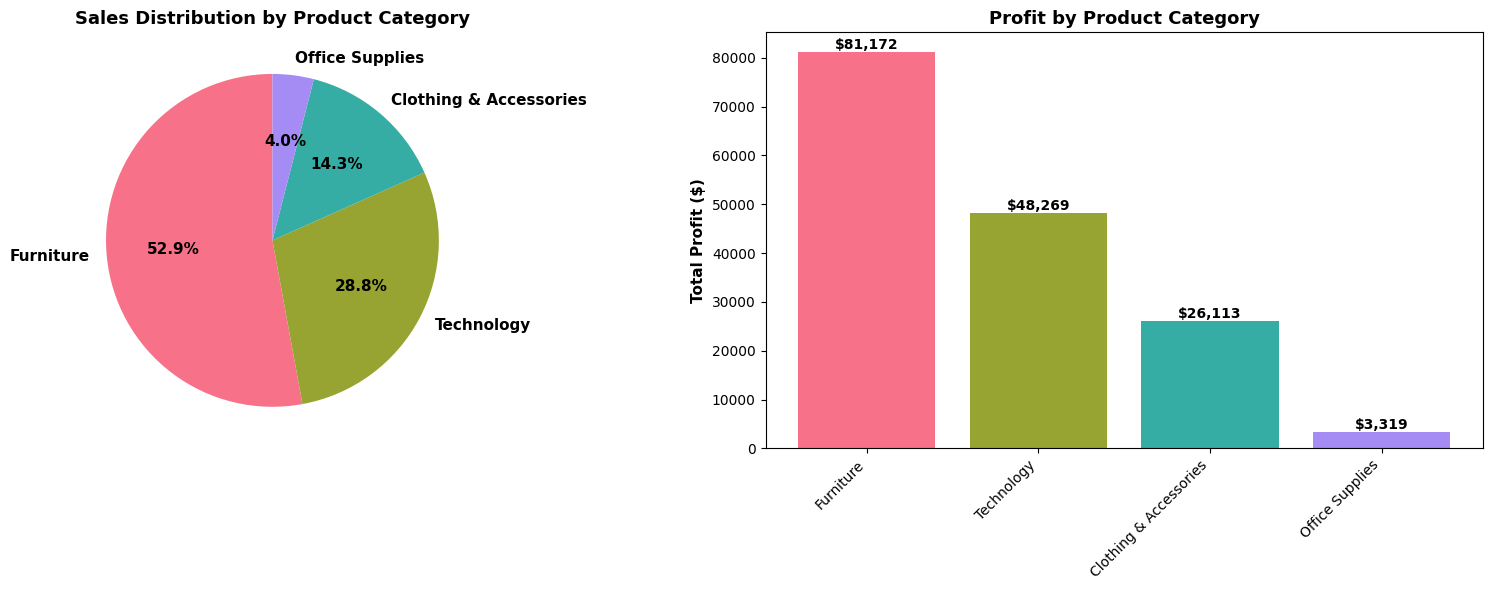


Product Category Performance:
                        Total_Sales  Total_Profit  Order_Count  \
Product_Category                                                 
Furniture                 256274.68      81171.57          507   
Technology                139518.22      48268.65          567   
Clothing & Accessories     69375.63      26112.94          413   
Office Supplies            19390.81       3319.16          513   

                        Total_Quantity  Profit_Margin  Avg_Order_Value  
Product_Category                                                        
Furniture                         1806          31.67           505.47  
Technology                        2017          34.60           246.06  
Clothing & Accessories            1551          37.64           167.98  
Office Supplies                   1741          17.12            37.80  


In [29]:
# Product Category Performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales by Category
category_sales = df.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=False)
colors = sns.color_palette('husl', len(category_sales))
axes[0].pie(category_sales.values, labels=category_sales.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Sales Distribution by Product Category', fontsize=13, fontweight='bold')

# Profit by Category
category_profit = df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)
bars = axes[1].bar(range(len(category_profit)), category_profit.values, color=colors)
axes[1].set_xticks(range(len(category_profit)))
axes[1].set_xticklabels(category_profit.index, rotation=45, ha='right')
axes[1].set_ylabel('Total Profit ($)', fontsize=11, fontweight='bold')
axes[1].set_title('Profit by Product Category', fontsize=13, fontweight='bold')

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'${height:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Detailed analysis
print("\nProduct Category Performance:")
category_analysis = df.groupby('Product_Category').agg({
    'Total_Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count',
    'Quantity': 'sum'
}).sort_values('Total_Sales', ascending=False)
category_analysis.columns = ['Total_Sales', 'Total_Profit', 'Order_Count', 'Total_Quantity']
category_analysis['Profit_Margin'] = (category_analysis['Total_Profit'] / category_analysis['Total_Sales'] * 100).round(2)
category_analysis['Avg_Order_Value'] = (category_analysis['Total_Sales'] / category_analysis['Order_Count']).round(2)
print(category_analysis)

## 3. Customer Segment Analysis

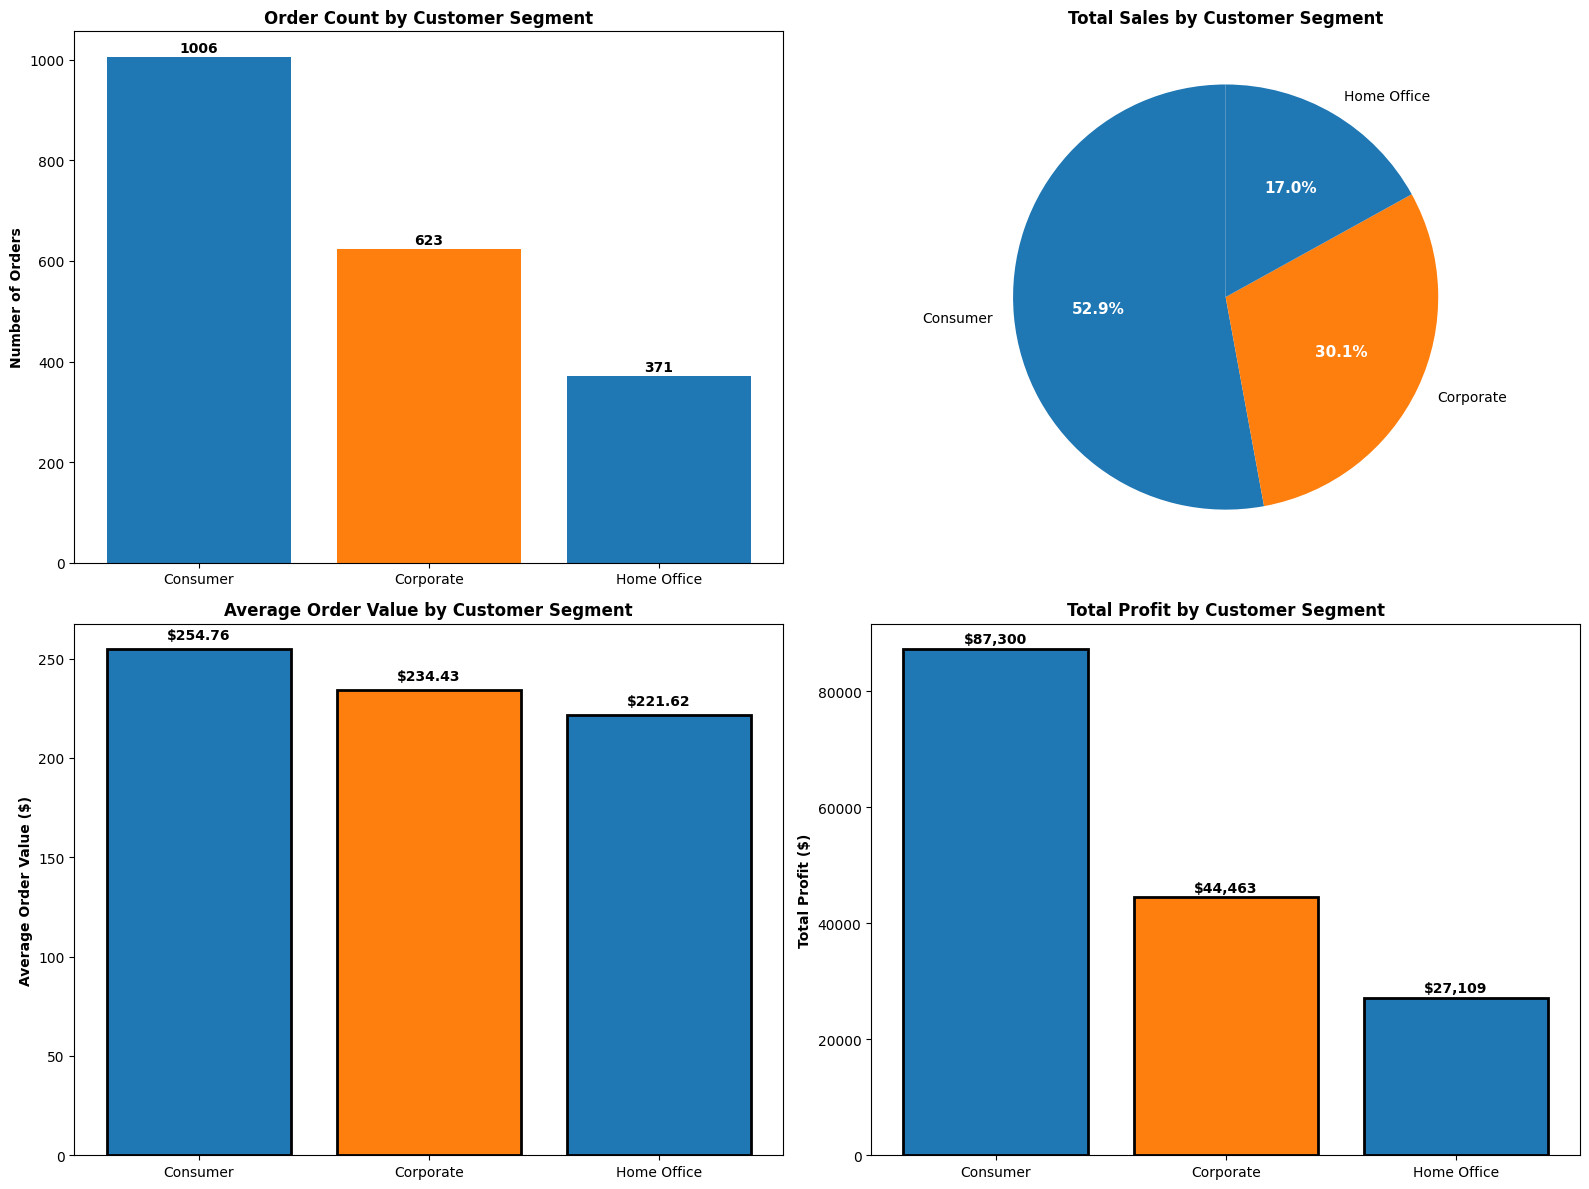


Customer Segment Performance:
                  Order_Count  Total_Sales  Avg_Sales  Median_Sales  \
Customer_Segment                                                      
Consumer                 1006    256287.74     254.76        113.18   
Corporate                 623    146050.39     234.43        110.95   
Home Office               371     82221.21     221.62        113.35   

                  Total_Profit  Avg_Profit  Avg_Discount  Profit_Margin  
Customer_Segment                                                         
Consumer              87300.36       86.78          7.20          34.06  
Corporate             44463.44       71.37         11.25          30.44  
Home Office           27108.52       73.07          7.80          32.97  


In [30]:
# Customer Segment Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Order Count by Segment
segment_orders = df['Customer_Segment'].value_counts()
axes[0, 0].bar(segment_orders.index, segment_orders.values, color=['#1f77b4', '#ff7f0e'])
axes[0, 0].set_ylabel('Number of Orders', fontweight='bold')
axes[0, 0].set_title('Order Count by Customer Segment', fontweight='bold', fontsize=12)
for i, v in enumerate(segment_orders.values):
    axes[0, 0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# 2. Sales by Segment
segment_sales = df.groupby('Customer_Segment')['Total_Sales'].sum()
colors_seg = ['#1f77b4', '#ff7f0e']
wedges, texts, autotexts = axes[0, 1].pie(segment_sales.values, labels=segment_sales.index, 
                                            autopct='%1.1f%%', colors=colors_seg, startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)
axes[0, 1].set_title('Total Sales by Customer Segment', fontweight='bold', fontsize=12)

# 3. Average Order Value by Segment
segment_aov = df.groupby('Customer_Segment')['Total_Sales'].mean()
axes[1, 0].bar(segment_aov.index, segment_aov.values, color=colors_seg, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Average Order Value ($)', fontweight='bold')
axes[1, 0].set_title('Average Order Value by Customer Segment', fontweight='bold', fontsize=12)
for i, v in enumerate(segment_aov.values):
    axes[1, 0].text(i, v + 5, f'${v:.2f}', ha='center', fontweight='bold')

# 4. Profit by Segment
segment_profit = df.groupby('Customer_Segment')['Profit'].sum()
axes[1, 1].bar(segment_profit.index, segment_profit.values, color=colors_seg, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Total Profit ($)', fontweight='bold')
axes[1, 1].set_title('Total Profit by Customer Segment', fontweight='bold', fontsize=12)
for i, v in enumerate(segment_profit.values):
    axes[1, 1].text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Detailed Segment Analysis
print("\nCustomer Segment Performance:")
segment_stats = df.groupby('Customer_Segment').agg({
    'Order_ID': 'count',
    'Total_Sales': ['sum', 'mean', 'median'],
    'Profit': ['sum', 'mean'],
    'Discount_Percent': 'mean'
}).round(2)
segment_stats.columns = ['Order_Count', 'Total_Sales', 'Avg_Sales', 'Median_Sales', 'Total_Profit', 'Avg_Profit', 'Avg_Discount']
segment_stats['Profit_Margin'] = (df.groupby('Customer_Segment')['Profit'].sum() / df.groupby('Customer_Segment')['Total_Sales'].sum() * 100).round(2)
print(segment_stats)

## 4. Regional Performance Analysis

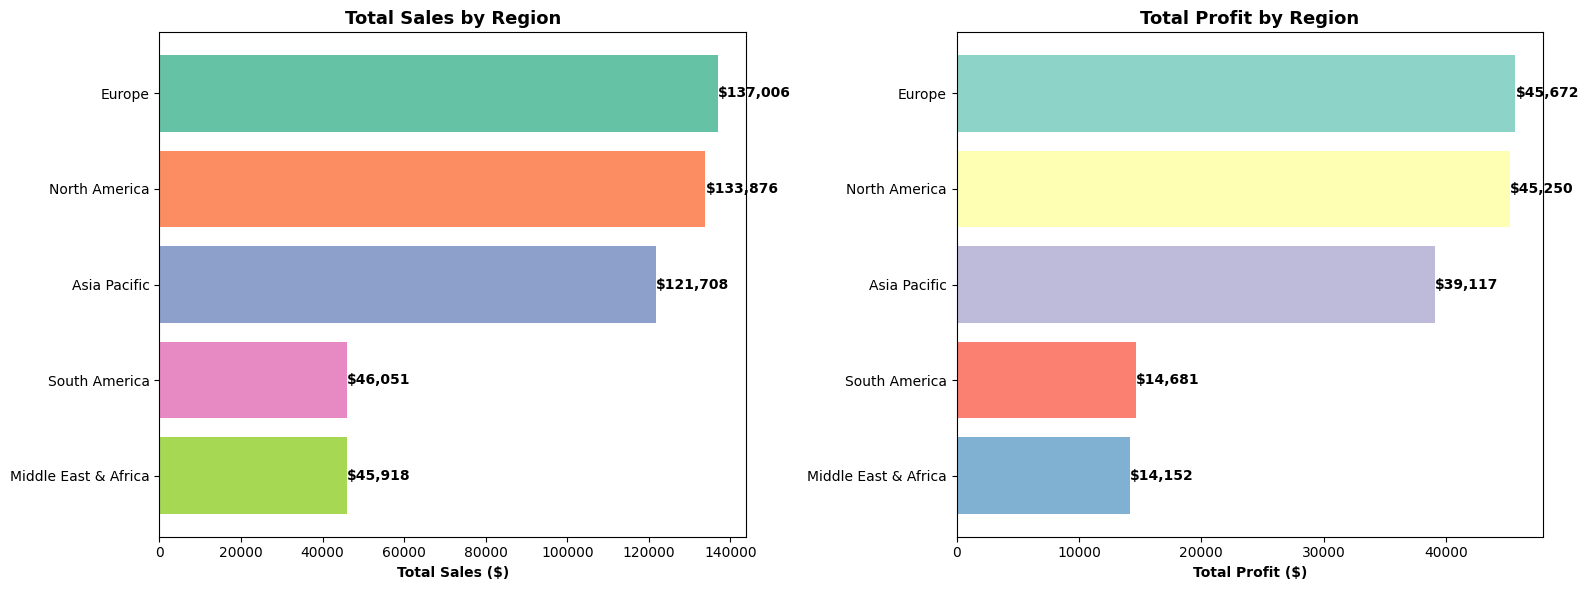


Regional Performance:
                      Order_Count  Total_Sales  Total_Profit  Total_Shipping  \
Region                                                                         
Europe                        503    137006.20      45672.16         6189.37   
North America                 578    133876.38      45250.09         5806.83   
Asia Pacific                  520    121707.51      39116.61         7531.15   
South America                 191     46051.13      14680.98         2949.85   
Middle East & Africa          208     45918.12      14152.48         3327.04   

                      Profit_Margin  Avg_Order_Value  
Region                                                
Europe                        33.34           272.38  
North America                 33.80           231.62  
Asia Pacific                  32.14           234.05  
South America                 31.88           241.11  
Middle East & Africa          30.82           220.76  


In [31]:
# Regional Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales by Region
region_sales = df.groupby('Region')['Total_Sales'].sum().sort_values(ascending=False)
bars1 = axes[0].barh(range(len(region_sales)), region_sales.values, color=sns.color_palette('Set2', len(region_sales)))
axes[0].set_yticks(range(len(region_sales)))
axes[0].set_yticklabels(region_sales.index)
axes[0].set_xlabel('Total Sales ($)', fontweight='bold')
axes[0].set_title('Total Sales by Region', fontweight='bold', fontsize=13)
axes[0].invert_yaxis()

for i, bar in enumerate(bars1):
    width = bar.get_width()
    axes[0].text(width, bar.get_y() + bar.get_height()/2, f'${width:,.0f}', 
                ha='left', va='center', fontweight='bold')

# Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
bars2 = axes[1].barh(range(len(region_profit)), region_profit.values, color=sns.color_palette('Set3', len(region_profit)))
axes[1].set_yticks(range(len(region_profit)))
axes[1].set_yticklabels(region_profit.index)
axes[1].set_xlabel('Total Profit ($)', fontweight='bold')
axes[1].set_title('Total Profit by Region', fontweight='bold', fontsize=13)
axes[1].invert_yaxis()

for i, bar in enumerate(bars2):
    width = bar.get_width()
    axes[1].text(width, bar.get_y() + bar.get_height()/2, f'${width:,.0f}', 
                ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Regional detailed stats
print("\nRegional Performance:")
regional_stats = df.groupby('Region').agg({
    'Order_ID': 'count',
    'Total_Sales': 'sum',
    'Profit': 'sum',
    'Shipping_Cost': 'sum'
}).sort_values('Total_Sales', ascending=False)
regional_stats.columns = ['Order_Count', 'Total_Sales', 'Total_Profit', 'Total_Shipping']
regional_stats['Profit_Margin'] = (regional_stats['Total_Profit'] / regional_stats['Total_Sales'] * 100).round(2)
regional_stats['Avg_Order_Value'] = (regional_stats['Total_Sales'] / regional_stats['Order_Count']).round(2)
print(regional_stats)

## 5. Payment Method Analysis

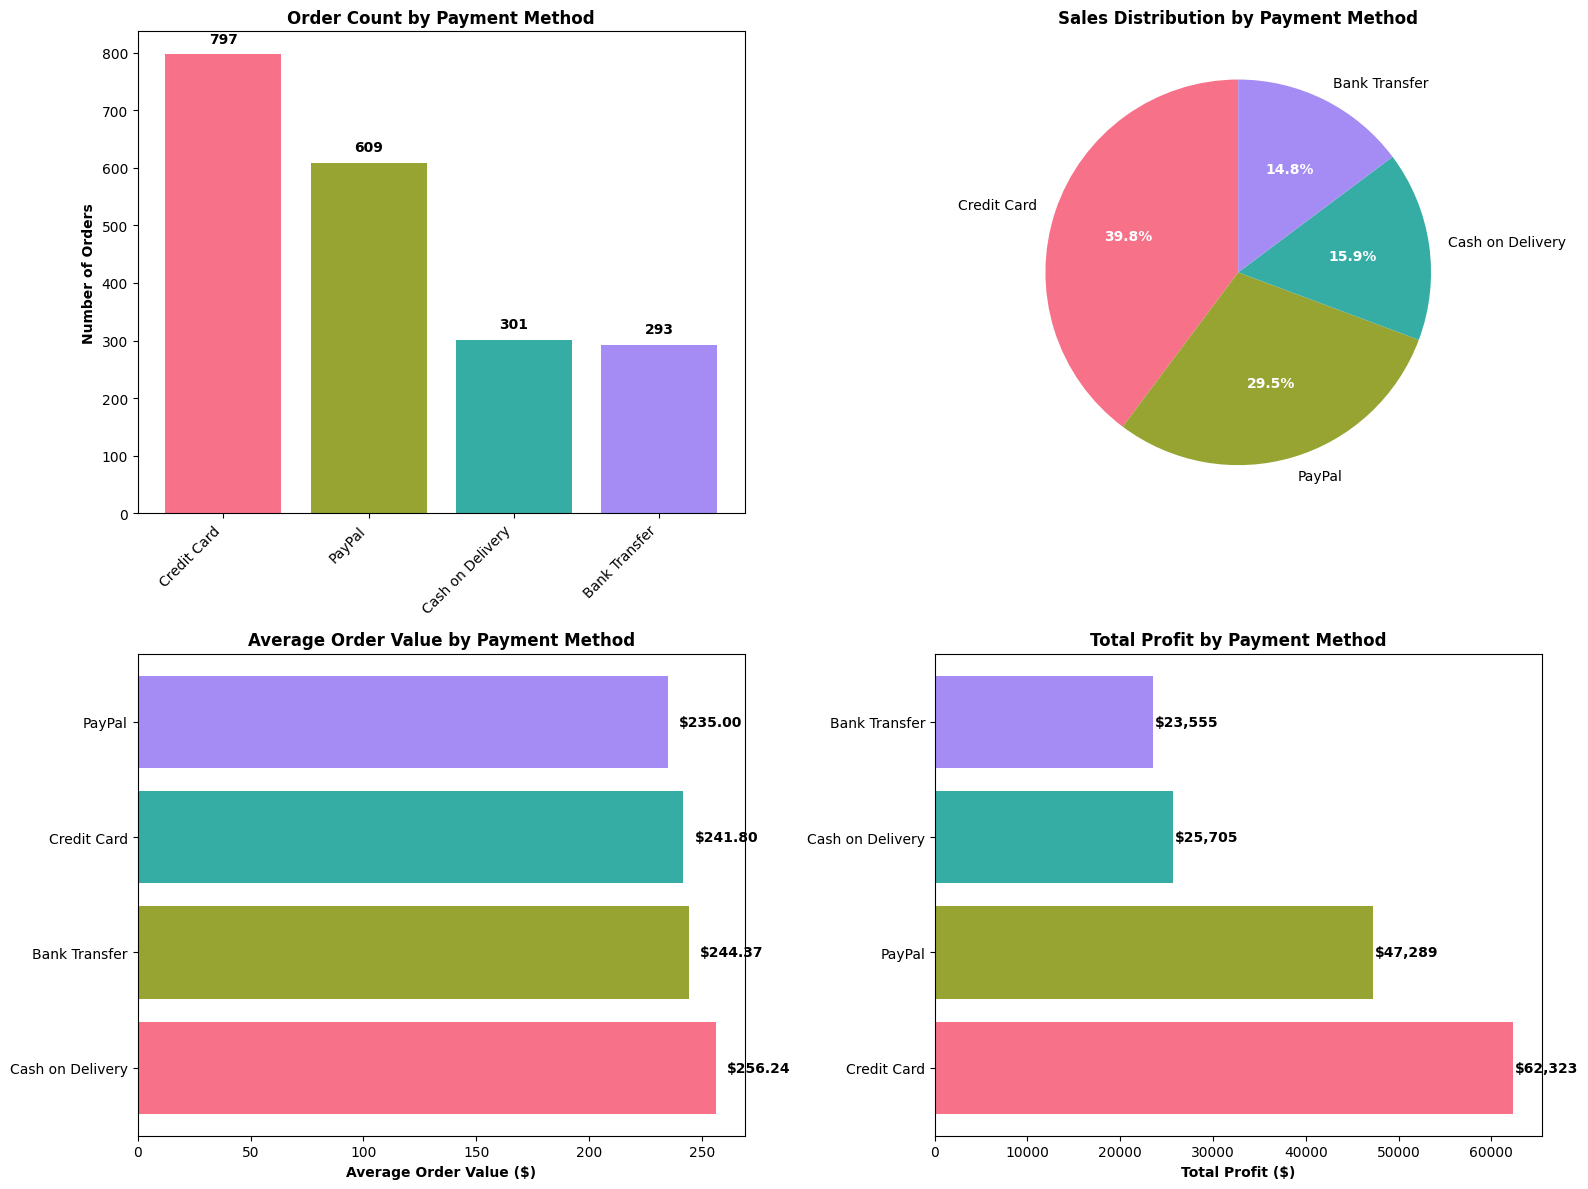


Payment Method Analysis:
                  Order_Count  Total_Sales  Avg_Sales  Total_Profit  \
Payment_Method                                                        
Credit Card               797    192717.89     241.80      62323.24   
PayPal                    609    143112.87     235.00      47288.80   
Cash on Delivery          301     77129.54     256.24      25704.89   
Bank Transfer             293     71599.04     244.37      23555.39   

                  Avg_Profit  Profit_Margin  
Payment_Method                               
Credit Card            78.20          32.34  
PayPal                 77.65          33.04  
Cash on Delivery       85.40          33.33  
Bank Transfer          80.39          32.90  


In [32]:
# Payment Method Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Order count by payment method
payment_orders = df['Payment_Method'].value_counts().sort_values(ascending=False)
axes[0, 0].bar(range(len(payment_orders)), payment_orders.values, color=sns.color_palette('husl', len(payment_orders)))
axes[0, 0].set_xticks(range(len(payment_orders)))
axes[0, 0].set_xticklabels(payment_orders.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Number of Orders', fontweight='bold')
axes[0, 0].set_title('Order Count by Payment Method', fontweight='bold', fontsize=12)
for i, v in enumerate(payment_orders.values):
    axes[0, 0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# 2. Sales by payment method
payment_sales = df.groupby('Payment_Method')['Total_Sales'].sum().sort_values(ascending=False)
colors_pay = sns.color_palette('husl', len(payment_sales))
wedges, texts, autotexts = axes[0, 1].pie(payment_sales.values, labels=payment_sales.index, 
                                           autopct='%1.1f%%', colors=colors_pay, startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
axes[0, 1].set_title('Sales Distribution by Payment Method', fontweight='bold', fontsize=12)

# 3. Average transaction value by payment method
payment_avg = df.groupby('Payment_Method')['Total_Sales'].mean().sort_values(ascending=False)
axes[1, 0].barh(range(len(payment_avg)), payment_avg.values, color=colors_pay)
axes[1, 0].set_yticks(range(len(payment_avg)))
axes[1, 0].set_yticklabels(payment_avg.index)
axes[1, 0].set_xlabel('Average Order Value ($)', fontweight='bold')
axes[1, 0].set_title('Average Order Value by Payment Method', fontweight='bold', fontsize=12)
for i, v in enumerate(payment_avg.values):
    axes[1, 0].text(v + 5, i, f'${v:.2f}', va='center', fontweight='bold')

# 4. Profit by payment method
payment_profit = df.groupby('Payment_Method')['Profit'].sum().sort_values(ascending=False)
axes[1, 1].barh(range(len(payment_profit)), payment_profit.values, color=colors_pay)
axes[1, 1].set_yticks(range(len(payment_profit)))
axes[1, 1].set_yticklabels(payment_profit.index)
axes[1, 1].set_xlabel('Total Profit ($)', fontweight='bold')
axes[1, 1].set_title('Total Profit by Payment Method', fontweight='bold', fontsize=12)
for i, v in enumerate(payment_profit.values):
    axes[1, 1].text(v + 200, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Payment method statistics
print("\nPayment Method Analysis:")
payment_stats = df.groupby('Payment_Method').agg({
    'Order_ID': 'count',
    'Total_Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean']
}).round(2)
payment_stats.columns = ['Order_Count', 'Total_Sales', 'Avg_Sales', 'Total_Profit', 'Avg_Profit']
payment_stats['Profit_Margin'] = (df.groupby('Payment_Method')['Profit'].sum() / df.groupby('Payment_Method')['Total_Sales'].sum() * 100).round(2)
print(payment_stats.sort_values('Total_Sales', ascending=False))

##  6. Sales Trends Over Time

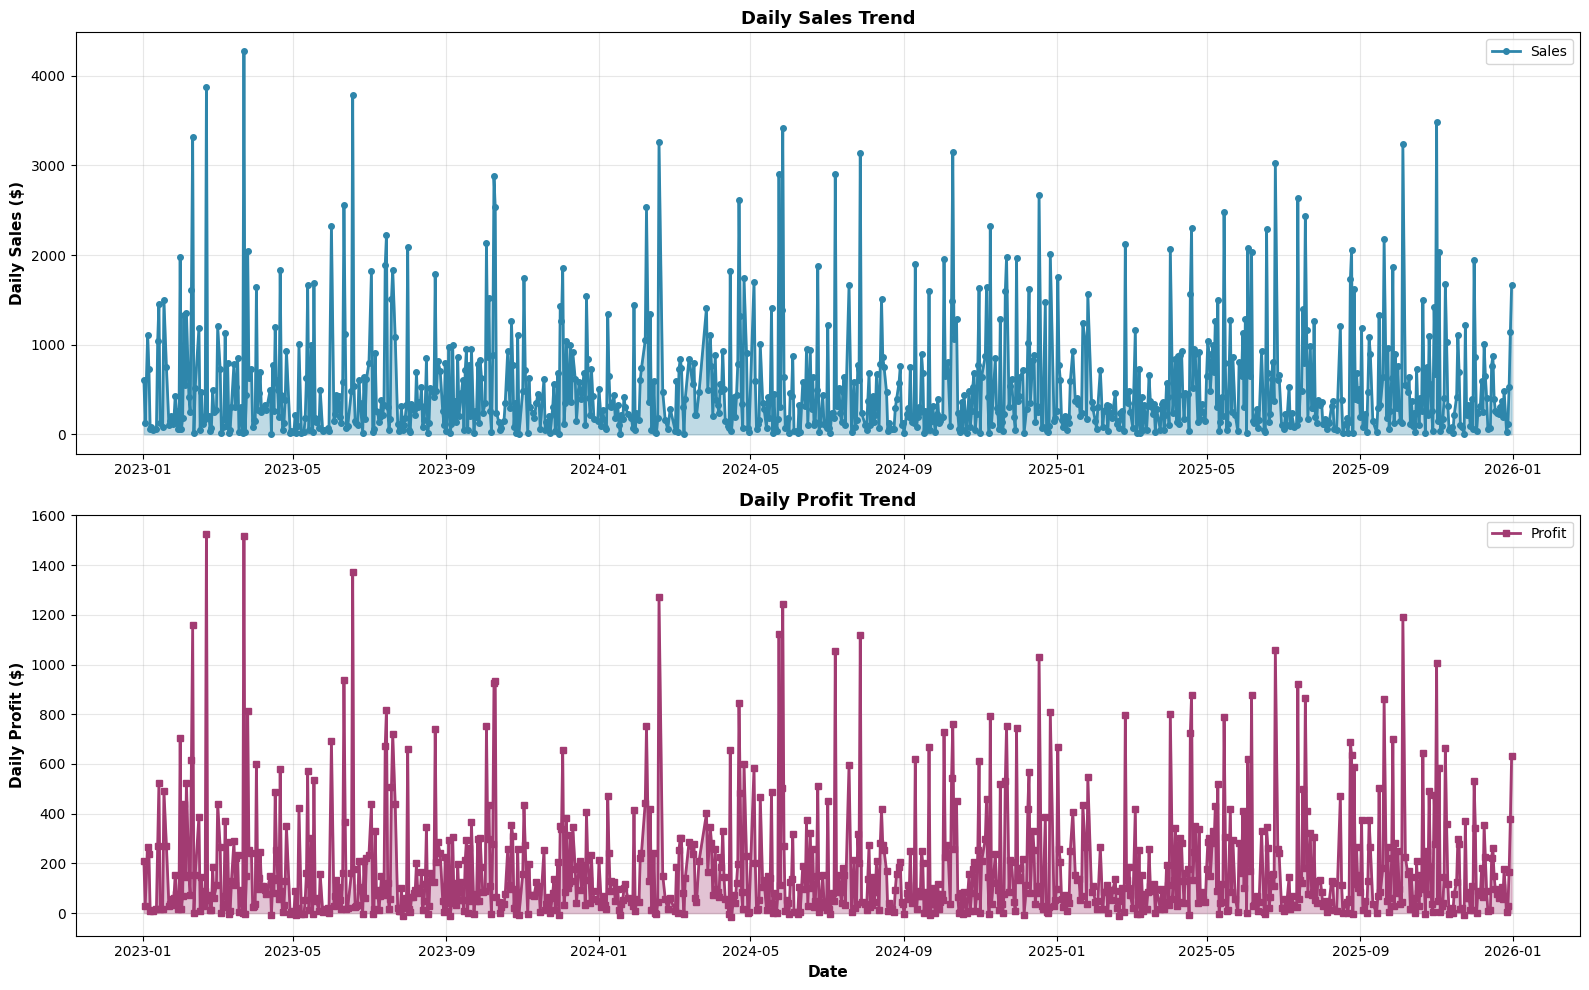


Monthly Performance Summary:
Year_Month  Total_Sales  Profit  Order_ID
   2023-01     11275.20 3573.01        47
   2023-02     16943.67 5980.06        52
   2023-03     16056.45 5718.77        51
   2023-04     12185.00 3994.25        48
   2023-05      8218.47 2591.86        40
   2023-06     16191.61 5240.34        59
   2023-07     15667.73 5195.97        59
   2023-08     12971.07 4216.32        69
   2023-09     11989.72 3577.00        58
   2023-10     17794.60 5573.05        63
   2023-11      8475.49 2469.77        46
   2023-12     16674.44 5023.34        78
   2024-01      8015.21 2490.14        48
   2024-02     11979.60 4131.26        36
   2024-03     10550.11 3583.31        44
   2024-04     15615.06 4900.65        68
   2024-05     16594.20 5909.30        63
   2024-06      9435.15 3051.84        44
   2024-07     14937.53 5137.37        50
   2024-08      9883.83 3198.94        53
   2024-09      9636.38 3094.84        60
   2024-10     17426.05 5443.33        76
   2

In [33]:
# Time Series Analysis
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Daily Sales and Profit Trend
daily_stats = df.groupby('Order_Date').agg({
    'Total_Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).reset_index()

# Sales trend
axes[0].plot(daily_stats['Order_Date'], daily_stats['Total_Sales'], marker='o', linewidth=2, 
             markersize=4, color='#2E86AB', label='Sales')
axes[0].fill_between(daily_stats['Order_Date'], daily_stats['Total_Sales'], alpha=0.3, color='#2E86AB')
axes[0].set_ylabel('Daily Sales ($)', fontsize=11, fontweight='bold')
axes[0].set_title('Daily Sales Trend', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Profit trend
axes[1].plot(daily_stats['Order_Date'], daily_stats['Profit'], marker='s', linewidth=2, 
             markersize=4, color='#A23B72', label='Profit')
axes[1].fill_between(daily_stats['Order_Date'], daily_stats['Profit'], alpha=0.3, color='#A23B72')
axes[1].set_ylabel('Daily Profit ($)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[1].set_title('Daily Profit Trend', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Monthly aggregation
df['Year_Month'] = df['Order_Date'].dt.to_period('M')
monthly_stats = df.groupby('Year_Month').agg({
    'Total_Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).reset_index()
monthly_stats['Year_Month'] = monthly_stats['Year_Month'].astype(str)

print("\nMonthly Performance Summary:")
print(monthly_stats.to_string(index=False))

# Calculate cumulative metrics
print("\nTrend Analysis:")
print(f"Date Range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")
print(f"Average Daily Sales: ${daily_stats['Total_Sales'].mean():,.2f}")
print(f"Average Daily Profit: ${daily_stats['Profit'].mean():,.2f}")
print(f"Average Daily Orders: {daily_stats['Order_ID'].mean():.0f}")